# Market Observation Notebook
### Goal: Observe and measure. No trading rules. No predictions. Only empirical facts.
### Output: A set of measured market behaviours that will calibrate the strategy notebook.
**Run cells top to bottom. Each phase is independent — you can run any phase alone after Cell 3.**

## Cell 1 — Installs & Imports

In [22]:
# ── Cell 1: Installs & Imports ─────────────────────────────────────────────
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scipy', 'seaborn', 'matplotlib', '-q'])

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 30)
plt.style.use('dark_background')
np.random.seed(42)

print('Imports complete.')

Imports complete.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = "/content/drive/MyDrive/Market Data/AggTrades/BTCUSDT-aggTrades-2021-01.zip"  # change this
extract_path = "/content/Market Data/AggTrades/extracted_data"

# Create folder
os.makedirs(extract_path, exist_ok=True)

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extracted to:", extract_path)

import pandas as pd

csv_path = os.path.join(extract_path, "BTCUSDT-aggTrades-2021-01.csv")
df = pd.read_csv(csv_path)

df.head()

Mounted at /content/drive
✅ Extracted to: /content/Market Data/AggTrades/extracted_data


## Cell 2 — Master Config
**All constants, paths, and parameters live here. Change nothing elsewhere.**

In [10]:
# ── Cell 2: Master Config ──────────────────────────────────────────────────

OBS = {

    # ── Data Paths ────────────────────────────────────────────────────────
    # Klines CSV: open_time, open, high, low, close, volume, close_time,
    #             quote_vol, count, taker_buy_volume, taker_buy_quote_volume, ignore
    'PATH_KLINES_1M'   : '/content/modified_BTCUSDT-1m-2020-01.csv',
    # AggTrades CSV: agg_trade_id, price, qty, first_trade_id, last_trade_id,
    #                transact_time, is_buyer_maker
    # Required for delta volume profile. Set None to skip delta profile.
    'PATH_AGGTRADES'   : '/content/Market Data/AggTrades/extracted_data/BTCUSDT-aggTrades-2021-01.csv',

    # ── Time Window ───────────────────────────────────────────────────────
    # How many days of data to load. Increase for more statistical power.
    # Recommended: 365+ days for robust profile analysis.
    'DAYS_TO_LOAD'     : 365,

    # ── Volume Profile Parameters ─────────────────────────────────────────
    # Price bucket size for volume profile (in USD)
    # Smaller = finer resolution, more noise. Larger = smoother, less detail.
    # For BTC at ~80k, 10 USD buckets give ~8000 price levels per session.
    'VP_BUCKET_SIZE'   : 10.0,
    # Value Area: fraction of total session volume that defines the value area
    'VP_VALUE_AREA'    : 0.70,
    # HVN threshold: a node is High Volume if its volume exceeds this
    # multiple of the session's median node volume
    'VP_HVN_MULT'      : 2.0,
    # LVN threshold: a node is Low Volume if its volume is below this
    # multiple of the session's median node volume
    'VP_LVN_MULT'      : 0.4,

    # ── Fractal / Multi-Timeframe Parameters ──────────────────────────────
    # Timeframes to analyse for Phase 2.
    # All are resampled from 1m data.
    'FRACTAL_TFS'      : ['1min', '5min', '15min', '60min'],
    # EMA period used to define trend direction on each timeframe
    # trend = +1 if close > EMA, -1 if close < EMA
    'FRACTAL_EMA'      : 20,
    # Minimum consecutive bars in same direction to count as a trend
    'FRACTAL_MIN_BARS' : 5,
    # Rolling window (in bars of each TF) for range/trend classification
    'FRACTAL_WINDOW'   : 50,

    # ── Phase 3: Volume at Key Moments ────────────────────────────────────
    # Bars before and after an event (reversal or breakout) to inspect
    'EVENT_LOOKBACK'   : 10,
    'EVENT_LOOKAHEAD'  : 10,
    # Minimum price move (as multiple of ATR) to qualify as a reversal
    'REVERSAL_ATR_MULT': 1.5,
    # Minimum price move to qualify as a breakout (multiple of ATR)
    'BREAKOUT_ATR_MULT': 1.5,
    # Volume multiple above rolling mean to count as high volume
    'HIGH_VOL_MULT'    : 1.5,
    # ATR period
    'ATR_PERIOD'       : 14,
    # Rolling window for volume baseline
    'VOL_MA_WINDOW'    : 20,

    # ── Phase 4: VWAP Parameters ─────────────────────────────────────────
    # Standard deviation bands for VWAP
    'VWAP_STD_BANDS'   : [1.0, 2.0],
    # Proximity threshold: price is "at" VWAP if within this fraction of price
    'VWAP_TOUCH_PCT'   : 0.0005,    # 0.05% of price
    # Number of bars to observe after a VWAP touch
    'VWAP_FWD_BARS'    : [5, 15, 30],
    # Previous session lookback for key level detection
    'PREV_SESSION_BARS': 1440,      # 1 day of 1m bars

    # ── Output ────────────────────────────────────────────────────────────
    'SAVE_PLOTS'       : True,
    'PLOT_DPI'         : 130,
    'BG'               : '#0d1117',
    'TEAL'             : '#00d4aa',
    'ORANGE'           : '#f7931a',
    'RED'              : '#e74c3c',
    'BLUE'             : '#3498db',
    'GREY'             : '#555555',
}

print('Config loaded.')
print(f"  Klines path  : {OBS['PATH_KLINES_1M']}")
print(f"  AggTrades    : {OBS['PATH_AGGTRADES']}")
print(f"  Days to load : {OBS['DAYS_TO_LOAD']}")
print(f"  VP bucket    : ${OBS['VP_BUCKET_SIZE']}")
print(f"  Fractal TFs  : {OBS['FRACTAL_TFS']}")

Config loaded.
  Klines path  : /content/modified_BTCUSDT-1m-2020-01.csv
  AggTrades    : None
  Days to load : 365
  VP bucket    : $10.0
  Fractal TFs  : ['1min', '5min', '15min', '60min']


## Cell 3 — Data Loader
Loads 1m klines and aggTrades, resamples to all required timeframes.
All data sorted by timestamp. AggTrades signed volume computed here.

In [11]:
# ── Cell 3: Data Loader ────────────────────────────────────────────────────

KLINE_COLS = [
    'open_time','open','high','low','close','volume','close_time',
    'quote_vol','count','taker_buy_volume','taker_buy_quote_volume','ignore'
]
AGGT_COLS = [
    'agg_trade_id','price','qty','first_trade_id',
    'last_trade_id','transact_time','is_buyer_maker'
]

def parse_ts(series):
    """Parse Binance timestamps (ms or us) to UTC DatetimeIndex."""
    s = pd.to_numeric(series, errors='coerce').dropna().astype(np.int64)
    unit = 'us' if s.iloc[0] > 1e15 else 'ms'
    return pd.to_datetime(s, unit=unit, utc=True)

def load_klines(path):
    df = pd.read_csv(path)
    if 'open_time' not in df.columns:
        df.columns = KLINE_COLS
    df = df.dropna(subset=['open_time'])
    df.index = parse_ts(df['open_time'])
    use_cols = ['open','high','low','close','volume','count',
                'taker_buy_volume','taker_buy_quote_volume']
    df = df[use_cols].apply(pd.to_numeric, errors='coerce')
    df = df[~df.index.duplicated(keep='first')].sort_index()
    print(f'  [klines 1m] {len(df):,} bars | {df.index[0].date()} → {df.index[-1].date()}')
    return df

def load_aggtrades(path):
    if path is None or not __import__('os').path.exists(path):
        print('  [aggTrades] Not found — delta profile will be skipped.')
        return None
    df = pd.read_csv(path)
    if 'transact_time' not in df.columns:
        df.columns = AGGT_COLS
    df = df.dropna(subset=['transact_time'])
    df.index = parse_ts(df['transact_time'])
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    qty_col = 'quantity' if 'quantity' in df.columns else 'qty'
    df['qty'] = pd.to_numeric(df[qty_col], errors='coerce')
    df['is_buyer_maker'] = df['is_buyer_maker'].astype(str).str.upper().isin(['TRUE','1','T'])
    # signed_qty: positive = taker was buyer, negative = taker was seller
    df['signed_qty'] = np.where(df['is_buyer_maker'], -df['qty'], df['qty'])
    df = df[['price','qty','signed_qty','is_buyer_maker']].sort_index()
    print(f'  [aggTrades] {len(df):,} ticks | {df.index[0].date()} → {df.index[-1].date()}')
    return df

def resample_klines(df_1m, rule):
    return df_1m.resample(rule).agg({
        'open':'first','high':'max','low':'min','close':'last',
        'volume':'sum','count':'sum',
        'taker_buy_volume':'sum','taker_buy_quote_volume':'sum'
    }).dropna(subset=['open'])

def clip_days(df, days):
    if df is None: return None
    cutoff = df.index[-1] - pd.Timedelta(days=days)
    return df[df.index >= cutoff]

def compute_atr(df, period=14):
    h, l, pc = df['high'], df['low'], df['close'].shift(1)
    tr = pd.concat([h-l, (h-pc).abs(), (l-pc).abs()], axis=1).max(axis=1)
    return tr.ewm(alpha=1/period, adjust=False).mean()

# ── Load ──────────────────────────────────────────────────────────────────
print('Loading data...')
df1m_raw = load_klines(OBS['PATH_KLINES_1M'])
df_aggt  = load_aggtrades(OBS['PATH_AGGTRADES'])

df1m_raw = clip_days(df1m_raw, OBS['DAYS_TO_LOAD'])
df_aggt  = clip_days(df_aggt,  OBS['DAYS_TO_LOAD'])

# ── Resample to all required timeframes ───────────────────────────────────
TF_MAP = {}
for tf in OBS['FRACTAL_TFS']:
    TF_MAP[tf] = resample_klines(df1m_raw, tf)
    print(f'  [{tf}] {len(TF_MAP[tf]):,} bars')

# ── ATR on 1m (used throughout) ───────────────────────────────────────────
df1m = df1m_raw.copy()
df1m['atr']    = compute_atr(df1m, OBS['ATR_PERIOD'])
df1m['vol_ma'] = df1m['volume'].rolling(OBS['VOL_MA_WINDOW']).mean()
df1m['vol_rel'] = df1m['volume'] / (df1m['vol_ma'] + 1e-10)
df1m['taker_ratio'] = df1m['taker_buy_volume'] / (df1m['volume'] + 1e-10)
df1m['date'] = df1m.index.date

print(f'\nReady. Date range: {df1m.index[0].date()} → {df1m.index[-1].date()}')
print(f'Total 1m bars: {len(df1m):,}')

Loading data...
  [klines 1m] 44,639 bars | 2020-01-01 → 2020-01-31
  [aggTrades] Not found — delta profile will be skipped.
  in] 44,639 bars
  in] 8,928 bars
  in] 2,976 bars
  in] 744 bars

Ready. Date range: 2020-01-01 → 2020-01-31
Total 1m bars: 44,639


## Phase 1 — Volume Profile + Delta Volume Profile
For each session (daily, weekly) compute:
- Regular volume profile → HVN, LVN, POC, Value Area
- Delta volume profile → net buying/selling per price level
- What happens when price revisits these levels in the next session
- Delta at the last touch before reversal (the retracement endpoint pattern)

In [12]:
# ── Phase 1A: Volume Profile Builder ──────────────────────────────────────

def build_volume_profile(df_bars, aggt_session, bucket_size, value_area_pct):
    """
    Build volume profile and delta profile for a session.

    If aggt_session is provided: uses real tick data for precise per-price delta.
    If aggt_session is None: approximates delta from taker_buy_volume column.

    Returns dict with:
        profile     : DataFrame indexed by price bucket with vol, delta, delta_pct
        poc         : Point of Control price (highest volume bucket)
        vah         : Value Area High
        val         : Value Area Low
        hvn         : list of HVN price levels
        lvn         : list of LVN price levels
        total_vol   : total session volume
        total_delta : net delta for session
    """
    price_min = df_bars['low'].min()
    price_max = df_bars['high'].max()
    buckets = np.arange(
        np.floor(price_min / bucket_size) * bucket_size,
        np.ceil(price_max  / bucket_size) * bucket_size + bucket_size,
        bucket_size
    )

    profile = pd.DataFrame({'price': buckets, 'vol': 0.0, 'delta': 0.0})
    profile = profile.set_index('price')

    if aggt_session is not None and len(aggt_session) > 0:
        # Precise: bin each trade into price bucket
        aggt_session = aggt_session.copy()
        aggt_session['bucket'] = (np.floor(
            aggt_session['price'] / bucket_size) * bucket_size)
        grp = aggt_session.groupby('bucket').agg(
            vol=('qty','sum'), delta=('signed_qty','sum'))
        profile.update(grp)
    else:
        # Approximate from klines: distribute bar volume across price range
        for _, bar in df_bars.iterrows():
            bar_buckets = buckets[
                (buckets >= bar['low'] - bucket_size/2) &
                (buckets <= bar['high'] + bucket_size/2)
            ]
            if len(bar_buckets) == 0:
                continue
            vol_per = bar['volume'] / len(bar_buckets)
            buy_vol = bar.get('taker_buy_volume', bar['volume'] * 0.5)
            sell_vol = bar['volume'] - buy_vol
            delta_per = (buy_vol - sell_vol) / len(bar_buckets)
            for b in bar_buckets:
                if b in profile.index:
                    profile.loc[b, 'vol']   += vol_per
                    profile.loc[b, 'delta'] += delta_per

    profile = profile[profile['vol'] > 0].copy()
    if len(profile) == 0:
        return None

    total_vol   = profile['vol'].sum()
    total_delta = profile['delta'].sum()
    profile['vol_pct']   = profile['vol']   / (total_vol + 1e-10)
    profile['delta_pct'] = profile['delta'] / (total_vol + 1e-10)  # delta as % of total vol

    # Point of Control
    poc = profile['vol'].idxmax()

    # Value Area: expand from POC until value_area_pct of volume is captured
    sorted_p = profile['vol'].sort_values(ascending=False)
    cum_vol = 0.0
    va_prices = []
    for price_lvl, vol in sorted_p.items():
        cum_vol += vol
        va_prices.append(price_lvl)
        if cum_vol >= total_vol * value_area_pct:
            break
    vah = max(va_prices)
    val = min(va_prices)

    # HVN / LVN
    median_vol = profile['vol'].median()
    hvn = profile[profile['vol'] > median_vol * OBS['VP_HVN_MULT']].index.tolist()
    lvn = profile[profile['vol'] < median_vol * OBS['VP_LVN_MULT']].index.tolist()

    return dict(
        profile=profile, poc=poc, vah=vah, val=val,
        hvn=hvn, lvn=lvn,
        total_vol=total_vol, total_delta=total_delta
    )

print('Volume profile builder defined.')

Volume profile builder defined.


In [13]:
# ── Phase 1B: Build Daily Profiles ────────────────────────────────────────
# For each day: build VP + delta VP
# Then measure what happens when next-day price touches each level

print('Building daily volume profiles...')

daily_profiles = {}
dates = sorted(df1m['date'].unique())

for date in dates:
    day_bars = df1m[df1m['date'] == date]
    if len(day_bars) < 60:
        continue

    # Get matching aggTrades for this day
    if df_aggt is not None:
        aggt_day = df_aggt[df_aggt.index.date == date]
    else:
        aggt_day = None

    vp = build_volume_profile(
        day_bars, aggt_day,
        OBS['VP_BUCKET_SIZE'], OBS['VP_VALUE_AREA']
    )
    if vp is not None:
        daily_profiles[date] = vp

print(f'Built {len(daily_profiles)} daily profiles.')

# ── Phase 1C: Measure next-session behaviour at each level type ────────────
# For each profile level type (POC, VAH, VAL, HVN, LVN),
# measure: did next-day price touch it? If yes, what was the
# forward return and vol at that touch?

touch_records = []  # each row = one level touch event

for i, date in enumerate(sorted(daily_profiles.keys())[:-1]):
    next_dates = sorted(daily_profiles.keys())[i+1:i+2]
    if not next_dates:
        continue
    next_date = next_dates[0]

    vp = daily_profiles[date]
    next_bars = df1m[df1m['date'] == next_date].copy()
    if len(next_bars) < 30:
        continue

    # Key levels from previous session
    levels = [
        ('POC', vp['poc'], vp['profile'].loc[vp['poc'], 'delta']
         if vp['poc'] in vp['profile'].index else 0),
        ('VAH', vp['vah'], 0),
        ('VAL', vp['val'], 0),
    ]
    for lvl in vp['hvn'][:5]:  # top 5 HVN
        d = vp['profile'].loc[lvl, 'delta'] if lvl in vp['profile'].index else 0
        levels.append(('HVN', lvl, d))
    for lvl in vp['lvn'][:5]:  # top 5 LVN
        d = vp['profile'].loc[lvl, 'delta'] if lvl in vp['profile'].index else 0
        levels.append(('LVN', lvl, d))

    next_prices = next_bars['close'].values
    next_vols   = next_bars['vol_rel'].values
    next_taker  = next_bars['taker_ratio'].values

    for level_type, level_price, level_delta in levels:
        # Proximity threshold
        threshold = level_price * OBS['VWAP_TOUCH_PCT'] * 10  # 0.5% proximity

        for j, (px, vr, tr) in enumerate(
                zip(next_prices, next_vols, next_taker)):
            if abs(px - level_price) <= threshold:
                # Touched — measure forward return
                fwd_bars = min(30, len(next_prices) - j - 1)
                if fwd_bars < 5:
                    continue
                fwd_ret_5  = (next_prices[min(j+5,  len(next_prices)-1)] / px - 1) * 100
                fwd_ret_15 = (next_prices[min(j+15, len(next_prices)-1)] / px - 1) * 100
                fwd_ret_30 = (next_prices[min(j+30, len(next_prices)-1)] / px - 1) * 100

                touch_records.append({
                    'date'       : next_date,
                    'level_type' : level_type,
                    'level_price': level_price,
                    'level_delta': level_delta,
                    'delta_sign' : 'BUY' if level_delta > 0 else 'SELL',
                    'touch_vol_rel' : vr,
                    'touch_taker'   : tr,
                    'fwd_ret_5'  : fwd_ret_5,
                    'fwd_ret_15' : fwd_ret_15,
                    'fwd_ret_30' : fwd_ret_30,
                })
                break  # only first touch per level per day

touch_df = pd.DataFrame(touch_records)
print(f'Touch events recorded: {len(touch_df):,}')
print('\nForward return by level type (30-bar, mean %):')
if len(touch_df) > 0:
    print(touch_df.groupby('level_type')['fwd_ret_30'].agg(['mean','std','count']).round(4))

Building daily volume profiles...
Built 31 daily profiles.
Touch events recorded: 239

Forward return by level type (30-bar, mean %):
              mean    std  count
level_type                      
HVN         0.0817 0.5509     97
LVN         0.2178 0.7956     72
POC        -0.0465 0.5641     24
VAH         0.1988 0.6869     24
VAL         0.0050 0.3804     22


In [14]:
# ── Phase 1D: Delta at Last Retracement Touch ──────────────────────────────
# Find sequences where price retraces and then reverses.
# Measure: what is the delta profile of the final bar before reversal?
# Does it consistently show exhaustion (delta opposing price direction)?

print('Analysing delta at retracement endpoints...')

# Work on 5m bars for this analysis
df5 = TF_MAP['5min'].copy()
df5['atr']       = compute_atr(df5, OBS['ATR_PERIOD'])
df5['taker_ratio'] = df5['taker_buy_volume'] / (df5['volume'] + 1e-10)
df5['log_ret']   = np.log(df5['close'] / df5['close'].shift(1))
df5['delta']     = df5['taker_buy_volume'] - (df5['volume'] - df5['taker_buy_volume'])
df5['delta_z']   = (df5['delta'] - df5['delta'].rolling(20).mean()) / \
                   (df5['delta'].rolling(20).std() + 1e-10)

# Identify local swing highs and lows as retracement endpoints
# Swing high: bar N has higher high than N-2, N-1, N+1, N+2
# Swing low:  bar N has lower low than surrounding bars
lookback = 3
swing_high = pd.Series(False, index=df5.index)
swing_low  = pd.Series(False, index=df5.index)

for i in range(lookback, len(df5) - lookback):
    window_highs = df5['high'].iloc[i-lookback:i+lookback+1]
    window_lows  = df5['low'].iloc[i-lookback:i+lookback+1]
    if df5['high'].iloc[i] == window_highs.max():
        swing_high.iloc[i] = True
    if df5['low'].iloc[i] == window_lows.min():
        swing_low.iloc[i] = True

# At each swing high: measure delta_z and what price does next 15 bars
retrace_records = []

sh_idx = df5.index[swing_high]
sl_idx = df5.index[swing_low]

for ts in sh_idx:
    loc = df5.index.get_loc(ts)
    if loc < 5 or loc > len(df5) - 16:
        continue
    bar = df5.iloc[loc]
    fwd_15 = (df5['close'].iloc[loc+15] / bar['close'] - 1) * 100
    # Prior 5 bars trend direction (were we going up into this swing high?)
    prior_ret = (bar['close'] / df5['close'].iloc[loc-5] - 1)
    retrace_records.append({
        'type'     : 'SWING_HIGH',
        'delta_z'  : bar['delta_z'],
        'taker'    : bar['taker_ratio'],
        'vol_rel'  : bar['volume'] / (df5['volume'].iloc[loc-20:loc].mean() + 1e-10),
        'prior_ret': prior_ret,
        'fwd_15'   : fwd_15,
        'reversed' : fwd_15 < -0.1,  # reversed if down >0.1% in next 15 bars
    })

for ts in sl_idx:
    loc = df5.index.get_loc(ts)
    if loc < 5 or loc > len(df5) - 16:
        continue
    bar = df5.iloc[loc]
    fwd_15 = (df5['close'].iloc[loc+15] / bar['close'] - 1) * 100
    prior_ret = (bar['close'] / df5['close'].iloc[loc-5] - 1)
    retrace_records.append({
        'type'     : 'SWING_LOW',
        'delta_z'  : bar['delta_z'],
        'taker'    : bar['taker_ratio'],
        'vol_rel'  : bar['volume'] / (df5['volume'].iloc[loc-20:loc].mean() + 1e-10),
        'prior_ret': prior_ret,
        'fwd_15'   : fwd_15,
        'reversed' : fwd_15 > 0.1,
    })

retrace_df = pd.DataFrame(retrace_records)

print(f'Swing points identified: {len(retrace_df):,}')
print(f'  Swing highs: {(retrace_df["type"]=="SWING_HIGH").sum():,}')
print(f'  Swing lows : {(retrace_df["type"]=="SWING_LOW").sum():,}')
print()

# Key question: is delta_z at reversed swings different from non-reversed?
for swing_type in ['SWING_HIGH','SWING_LOW']:
    sub = retrace_df[retrace_df['type']==swing_type]
    rev = sub[sub['reversed']==True]['delta_z']
    cont = sub[sub['reversed']==False]['delta_z']
    if len(rev) > 10 and len(cont) > 10:
        stat, pval = stats.mannwhitneyu(rev, cont, alternative='two-sided')
        print(f'{swing_type}:')
        print(f'  Reversed  delta_z mean: {rev.mean():.3f}  (n={len(rev)})')
        print(f'  Continued delta_z mean: {cont.mean():.3f}  (n={len(cont)})')
        print(f'  Mann-Whitney p-value  : {pval:.4f}')
        print(f'  Interpretation: {"Delta differs at reversals" if pval < 0.05 else "No significant difference"}')
        print()

Analysing delta at retracement endpoints...
Swing points identified: 1,883
  Swing highs: 948
  Swing lows : 935

SWING_HIGH:
  Reversed  delta_z mean: 0.359  (n=491)
  Continued delta_z mean: 0.255  (n=457)
  Mann-Whitney p-value  : nan
  Interpretation: No significant difference

SWING_LOW:
  Reversed  delta_z mean: -0.464  (n=513)
  Continued delta_z mean: -0.335  (n=422)
  Mann-Whitney p-value  : nan
  Interpretation: No significant difference



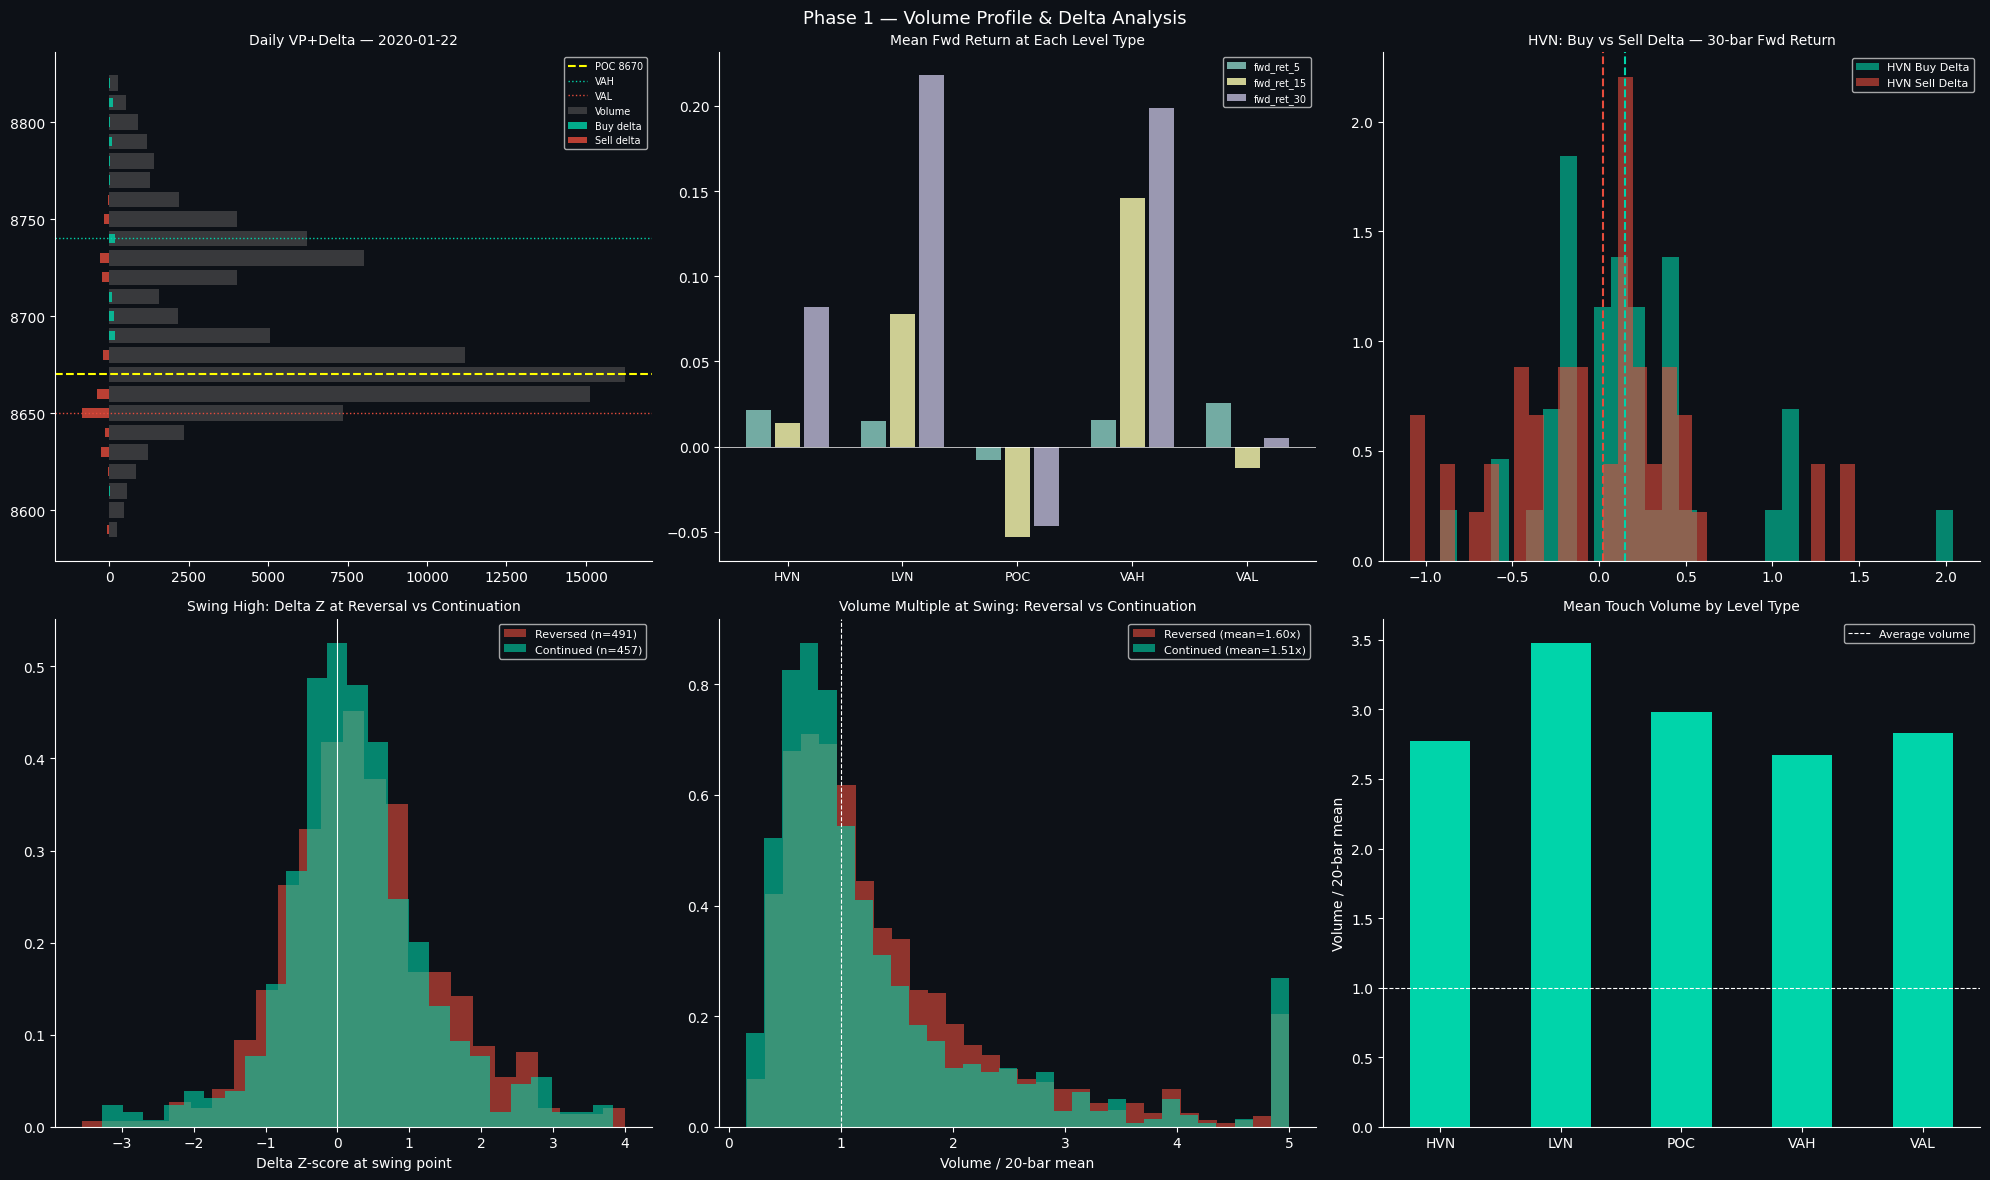

Phase 1 plots saved.


In [15]:
# ── Phase 1E: Volume Profile Observation Plots ─────────────────────────────

if len(touch_df) > 0 and len(daily_profiles) > 0:
    BG, TEAL, ORG, RED = OBS['BG'], OBS['TEAL'], OBS['ORANGE'], OBS['RED']

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.patch.set_facecolor(BG)
    fig.suptitle('Phase 1 — Volume Profile & Delta Analysis', color='white', fontsize=13)

    # Plot 1: Sample daily volume profile with delta overlay
    ax = axes[0, 0]
    ax.set_facecolor(BG)
    sample_date = sorted(daily_profiles.keys())[-10]  # 10th most recent day
    vp_s = daily_profiles[sample_date]
    prof = vp_s['profile'].sort_index()
    colors = [TEAL if d >= 0 else RED for d in prof['delta']]
    ax.barh(prof.index, prof['vol'], height=OBS['VP_BUCKET_SIZE']*0.8,
            color=OBS['GREY'], alpha=0.6, label='Volume')
    ax.barh(prof.index, prof['delta'].clip(lower=0), height=OBS['VP_BUCKET_SIZE']*0.5,
            color=TEAL, alpha=0.8, label='Buy delta')
    ax.barh(prof.index, prof['delta'].clip(upper=0), height=OBS['VP_BUCKET_SIZE']*0.5,
            color=RED, alpha=0.8, label='Sell delta')
    ax.axhline(vp_s['poc'], color='yellow', lw=1.5, ls='--', label=f'POC {vp_s["poc"]:.0f}')
    ax.axhline(vp_s['vah'], color=TEAL, lw=1, ls=':', label='VAH')
    ax.axhline(vp_s['val'], color=RED, lw=1, ls=':', label='VAL')
    ax.set_title(f'Daily VP+Delta — {sample_date}', color='white', fontsize=10)
    ax.tick_params(colors='white')
    ax.legend(fontsize=7, labelcolor='white', facecolor=BG)
    ax.spines[['top','right']].set_visible(False)

    # Plot 2: Forward return by level type
    ax = axes[0, 1]
    ax.set_facecolor(BG)
    for i, fwd_col in enumerate(['fwd_ret_5','fwd_ret_15','fwd_ret_30']):
        grp = touch_df.groupby('level_type')[fwd_col].mean()
        ax.bar(np.arange(len(grp)) + i*0.25, grp.values, width=0.22,
               label=fwd_col, alpha=0.8)
    ax.set_xticks(np.arange(len(grp)) + 0.25)
    ax.set_xticklabels(grp.index, color='white', fontsize=9)
    ax.axhline(0, color='white', lw=0.5)
    ax.set_title('Mean Fwd Return at Each Level Type', color='white', fontsize=10)
    ax.tick_params(colors='white')
    ax.legend(fontsize=7, labelcolor='white', facecolor=BG)
    ax.spines[['top','right']].set_visible(False)

    # Plot 3: Delta sign at HVN — buy delta vs sell delta forward return
    ax = axes[0, 2]
    ax.set_facecolor(BG)
    hvn_sub = touch_df[touch_df['level_type']=='HVN']
    if len(hvn_sub) > 20:
        buy_hvn  = hvn_sub[hvn_sub['delta_sign']=='BUY']['fwd_ret_30']
        sell_hvn = hvn_sub[hvn_sub['delta_sign']=='SELL']['fwd_ret_30']
        ax.hist(buy_hvn,  bins=30, color=TEAL, alpha=0.6, density=True, label='HVN Buy Delta')
        ax.hist(sell_hvn, bins=30, color=RED,  alpha=0.6, density=True, label='HVN Sell Delta')
        ax.axvline(buy_hvn.mean(),  color=TEAL, lw=1.5, ls='--')
        ax.axvline(sell_hvn.mean(), color=RED,  lw=1.5, ls='--')
    ax.set_title('HVN: Buy vs Sell Delta — 30-bar Fwd Return', color='white', fontsize=10)
    ax.tick_params(colors='white')
    ax.legend(fontsize=8, labelcolor='white', facecolor=BG)
    ax.spines[['top','right']].set_visible(False)

    # Plot 4: Swing reversal delta_z distribution
    ax = axes[1, 0]
    ax.set_facecolor(BG)
    if len(retrace_df) > 20:
        rev_sh  = retrace_df[(retrace_df['type']=='SWING_HIGH') & (retrace_df['reversed'])]['delta_z']
        cont_sh = retrace_df[(retrace_df['type']=='SWING_HIGH') & (~retrace_df['reversed'])]['delta_z']
        ax.hist(rev_sh.clip(-4,4),  bins=25, color=RED,  alpha=0.6, density=True,
                label=f'Reversed (n={len(rev_sh)})')
        ax.hist(cont_sh.clip(-4,4), bins=25, color=TEAL, alpha=0.6, density=True,
                label=f'Continued (n={len(cont_sh)})')
        ax.axvline(0, color='white', lw=0.8)
    ax.set_title('Swing High: Delta Z at Reversal vs Continuation', color='white', fontsize=10)
    ax.set_xlabel('Delta Z-score at swing point', color='white')
    ax.tick_params(colors='white')
    ax.legend(fontsize=8, labelcolor='white', facecolor=BG)
    ax.spines[['top','right']].set_visible(False)

    # Plot 5: Volume relative to mean at reversals vs continuations
    ax = axes[1, 1]
    ax.set_facecolor(BG)
    if len(retrace_df) > 20:
        rev_vol  = retrace_df[retrace_df['reversed']]['vol_rel']
        cont_vol = retrace_df[~retrace_df['reversed']]['vol_rel']
        ax.hist(rev_vol.clip(0,5),  bins=30, color=RED,  alpha=0.6, density=True,
                label=f'Reversed (mean={rev_vol.mean():.2f}x)')
        ax.hist(cont_vol.clip(0,5), bins=30, color=TEAL, alpha=0.6, density=True,
                label=f'Continued (mean={cont_vol.mean():.2f}x)')
        ax.axvline(1.0, color='white', lw=0.8, ls='--')
    ax.set_title('Volume Multiple at Swing: Reversal vs Continuation', color='white', fontsize=10)
    ax.set_xlabel('Volume / 20-bar mean', color='white')
    ax.tick_params(colors='white')
    ax.legend(fontsize=8, labelcolor='white', facecolor=BG)
    ax.spines[['top','right']].set_visible(False)

    # Plot 6: Touch volume at different level types
    ax = axes[1, 2]
    ax.set_facecolor(BG)
    grp_vol = touch_df.groupby('level_type')['touch_vol_rel'].mean()
    c = [TEAL if v > 1 else RED for v in grp_vol.values]
    ax.bar(grp_vol.index, grp_vol.values, color=c, width=0.5)
    ax.axhline(1.0, color='white', lw=0.8, ls='--', label='Average volume')
    ax.set_title('Mean Touch Volume by Level Type', color='white', fontsize=10)
    ax.set_ylabel('Volume / 20-bar mean', color='white')
    ax.tick_params(colors='white')
    ax.legend(fontsize=8, labelcolor='white', facecolor=BG)
    ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    if OBS['SAVE_PLOTS']:
        plt.savefig('phase1_volume_profile.png', dpi=OBS['PLOT_DPI'],
                    bbox_inches='tight', facecolor=BG)
    plt.show()
    print('Phase 1 plots saved.')

## Phase 2 — Fractal Structure: Range vs Trend Across Timeframes
Measures trend/range characteristics on 1m, 5m, 15m, 1h independently.
Tests whether 1m is structurally different from higher timeframes.
Identifies fractal alignment moments (all TFs agree on direction).

In [16]:
# ── Phase 2A: Per-Timeframe Trend/Range Statistics ─────────────────────────

def compute_tf_features(df, tf_name, ema_period, window):
    """
    For each bar compute:
    - EMA-based trend direction (+1 / -1)
    - Directional efficiency: net displacement / total path
    - Range width normalised by ATR
    - Volume efficiency: price move per unit volume
    """
    df = df.copy()
    df['ema']         = df['close'].ewm(span=ema_period, adjust=False).mean()
    df['trend_dir']   = np.where(df['close'] > df['ema'], 1, -1)
    df['log_ret']     = np.log(df['close'] / df['close'].shift(1))
    df['atr']         = compute_atr(df)

    # Directional efficiency over rolling window
    # = |net return| / sum(|bar returns|) — 1.0 = perfect trend, 0 = pure chop
    net_ret   = df['log_ret'].rolling(window).sum().abs()
    total_ret = df['log_ret'].abs().rolling(window).sum()
    df['dir_efficiency'] = net_ret / (total_ret + 1e-10)

    # Range width / ATR
    roll_high = df['high'].rolling(window).max()
    roll_low  = df['low'].rolling(window).min()
    df['range_atr'] = (roll_high - roll_low) / (df['atr'] * np.sqrt(window) + 1e-10)

    # Volume efficiency: |close - open| / volume (normalised)
    df['vol_efficiency'] = (df['close'] - df['open']).abs() / (df['volume'] + 1e-10)
    df['vol_eff_z']      = (df['vol_efficiency'] -
                            df['vol_efficiency'].rolling(window).mean()) / \
                           (df['vol_efficiency'].rolling(window).std() + 1e-10)

    df['tf'] = tf_name
    return df.dropna(subset=['dir_efficiency','range_atr'])

print('Computing fractal features across all timeframes...')

tf_features = {}
for tf in OBS['FRACTAL_TFS']:
    tf_features[tf] = compute_tf_features(
        TF_MAP[tf], tf,
        OBS['FRACTAL_EMA'],
        OBS['FRACTAL_WINDOW']
    )
    df_tf = tf_features[tf]
    print(f'  [{tf}] bars={len(df_tf):,} | '
          f'mean dir_efficiency={df_tf["dir_efficiency"].mean():.3f} | '
          f'mean range_atr={df_tf["range_atr"].mean():.3f}')

# Statistical comparison: is 1m different from 5m, 15m, 1h?
print('\nKruskal-Wallis test — Directional Efficiency across timeframes:')
samples = [tf_features[tf]['dir_efficiency'].dropna().values
           for tf in OBS['FRACTAL_TFS']]
stat, p = stats.kruskal(*samples)
print(f'  H-statistic: {stat:.2f}  p-value: {p:.6f}')
print(f'  Interpretation: {"Timeframes are statistically DIFFERENT" if p < 0.05 else "No significant difference"}')

# Pairwise comparison of 1m vs each other TF
print('\nMann-Whitney pairwise vs 1m:')
ref = tf_features['1min']['dir_efficiency'].dropna().values
for tf in OBS['FRACTAL_TFS'][1:]:
    other = tf_features[tf]['dir_efficiency'].dropna().values
    stat_mw, p_mw = stats.mannwhitneyu(ref, other, alternative='two-sided')
    print(f'  1m vs {tf:<6}: p={p_mw:.6f} {"*DIFFERENT*" if p_mw < 0.01 else "similar"}')

Computing fractal features across all timeframes...
  in] bars=44,589 | mean dir_efficiency=0.116 | mean range_atr=1.153
  in] bars=8,878 | mean dir_efficiency=0.122 | mean range_atr=1.056
  in] bars=2,926 | mean dir_efficiency=0.146 | mean range_atr=1.095
  in] bars=694 | mean dir_efficiency=0.180 | mean range_atr=1.095

Kruskal-Wallis test — Directional Efficiency across timeframes:
  H-statistic: 260.72  p-value: 0.000000
  Interpretation: Timeframes are statistically DIFFERENT

Mann-Whitney pairwise vs 1m:
  1m vs 5min  : p=0.001711 *DIFFERENT*
  1m vs 15min : p=0.000000 *DIFFERENT*
  1m vs 60min : p=0.000000 *DIFFERENT*


In [17]:
# ── Phase 2B: Fractal Alignment Detection ─────────────────────────────────
# Find bars where all timeframes agree on trend direction.
# Measure forward return at alignment transitions.

print('Building fractal alignment index...')

# Align all timeframe directions to 1m index
align_df = pd.DataFrame(index=df1m.index)

for tf in OBS['FRACTAL_TFS']:
    dir_series = tf_features[tf]['trend_dir']
    # Forward fill: 1m bar inherits last known direction from higher TF
    aligned = dir_series.reindex(df1m.index, method='ffill')
    align_df[f'dir_{tf}'] = aligned

align_df = align_df.dropna()

# Alignment score: sum of directions (-4 to +4)
# +4 = all TFs bullish, -4 = all TFs bearish, 0 = mixed
dir_cols = [f'dir_{tf}' for tf in OBS['FRACTAL_TFS']]
align_df['align_score'] = align_df[dir_cols].sum(axis=1)
align_df['full_bull']   = align_df['align_score'] == len(OBS['FRACTAL_TFS'])
align_df['full_bear']   = align_df['align_score'] == -len(OBS['FRACTAL_TFS'])
align_df['mixed']       = align_df['align_score'].abs() < len(OBS['FRACTAL_TFS'])

# Transition: bars where alignment just became full (was mixed, now full)
align_df['prev_score']  = align_df['align_score'].shift(1)
align_df['bull_entry']  = (align_df['full_bull']) & (align_df['prev_score'].abs() < len(OBS['FRACTAL_TFS']))
align_df['bear_entry']  = (align_df['full_bear']) & (align_df['prev_score'].abs() < len(OBS['FRACTAL_TFS']))

# Merge with 1m close for forward return calculation
align_df['close'] = df1m['close'].reindex(align_df.index)

# Measure forward return at alignment transitions
align_records = []
closes = df1m['close'].values
idx1m  = df1m.index

for signal_type, mask in [('BULL_ALIGN', align_df['bull_entry']),
                           ('BEAR_ALIGN', align_df['bear_entry'])]:
    signal_ts = align_df[mask].index
    for ts in signal_ts:
        loc = np.searchsorted(idx1m, ts)
        if loc >= len(idx1m) - 60:
            continue
        entry_px = closes[loc]
        direction = 1 if signal_type == 'BULL_ALIGN' else -1
        for fwd in [5, 15, 30, 60]:
            if loc + fwd < len(closes):
                ret = direction * (closes[loc+fwd] / entry_px - 1) * 100
                align_records.append({
                    'type': signal_type,
                    'fwd_bars': fwd,
                    'ret_pct': ret
                })

align_results = pd.DataFrame(align_records)

print(f'\nAlignment statistics on 1m bars:')
n = len(align_df)
print(f'  Full bullish alignment : {align_df["full_bull"].sum():,} bars ({align_df["full_bull"].mean()*100:.1f}%)')
print(f'  Full bearish alignment : {align_df["full_bear"].sum():,} bars ({align_df["full_bear"].mean()*100:.1f}%)')
print(f'  Mixed (no consensus)   : {align_df["mixed"].sum():,} bars ({align_df["mixed"].mean()*100:.1f}%)')
print(f'  Bull transitions       : {align_df["bull_entry"].sum():,}')
print(f'  Bear transitions       : {align_df["bear_entry"].sum():,}')

if len(align_results) > 0:
    print('\nForward return at alignment transitions (mean %):')
    print(align_results.groupby(['type','fwd_bars'])['ret_pct'].agg(
        mean='mean', positive_pct=lambda x: (x>0).mean()
    ).round(4))

Building fractal alignment index...

Alignment statistics on 1m bars:
  Full bullish alignment : 11,695 bars (28.1%)
  Full bearish alignment : 6,885 bars (16.5%)
  Mixed (no consensus)   : 23,060 bars (55.4%)
  Bull transitions       : 1,333
  Bear transitions       : 743

Forward return at alignment transitions (mean %):
                      mean  positive_pct
type       fwd_bars                     
BEAR_ALIGN 5        0.0541        0.6595
           15       0.0665        0.5976
           30       0.0814        0.5801
           60       0.0868        0.5410
BULL_ALIGN 5        0.0386        0.6346
           15       0.0589        0.5962
           30       0.0836        0.5729
           60       0.1152        0.5474


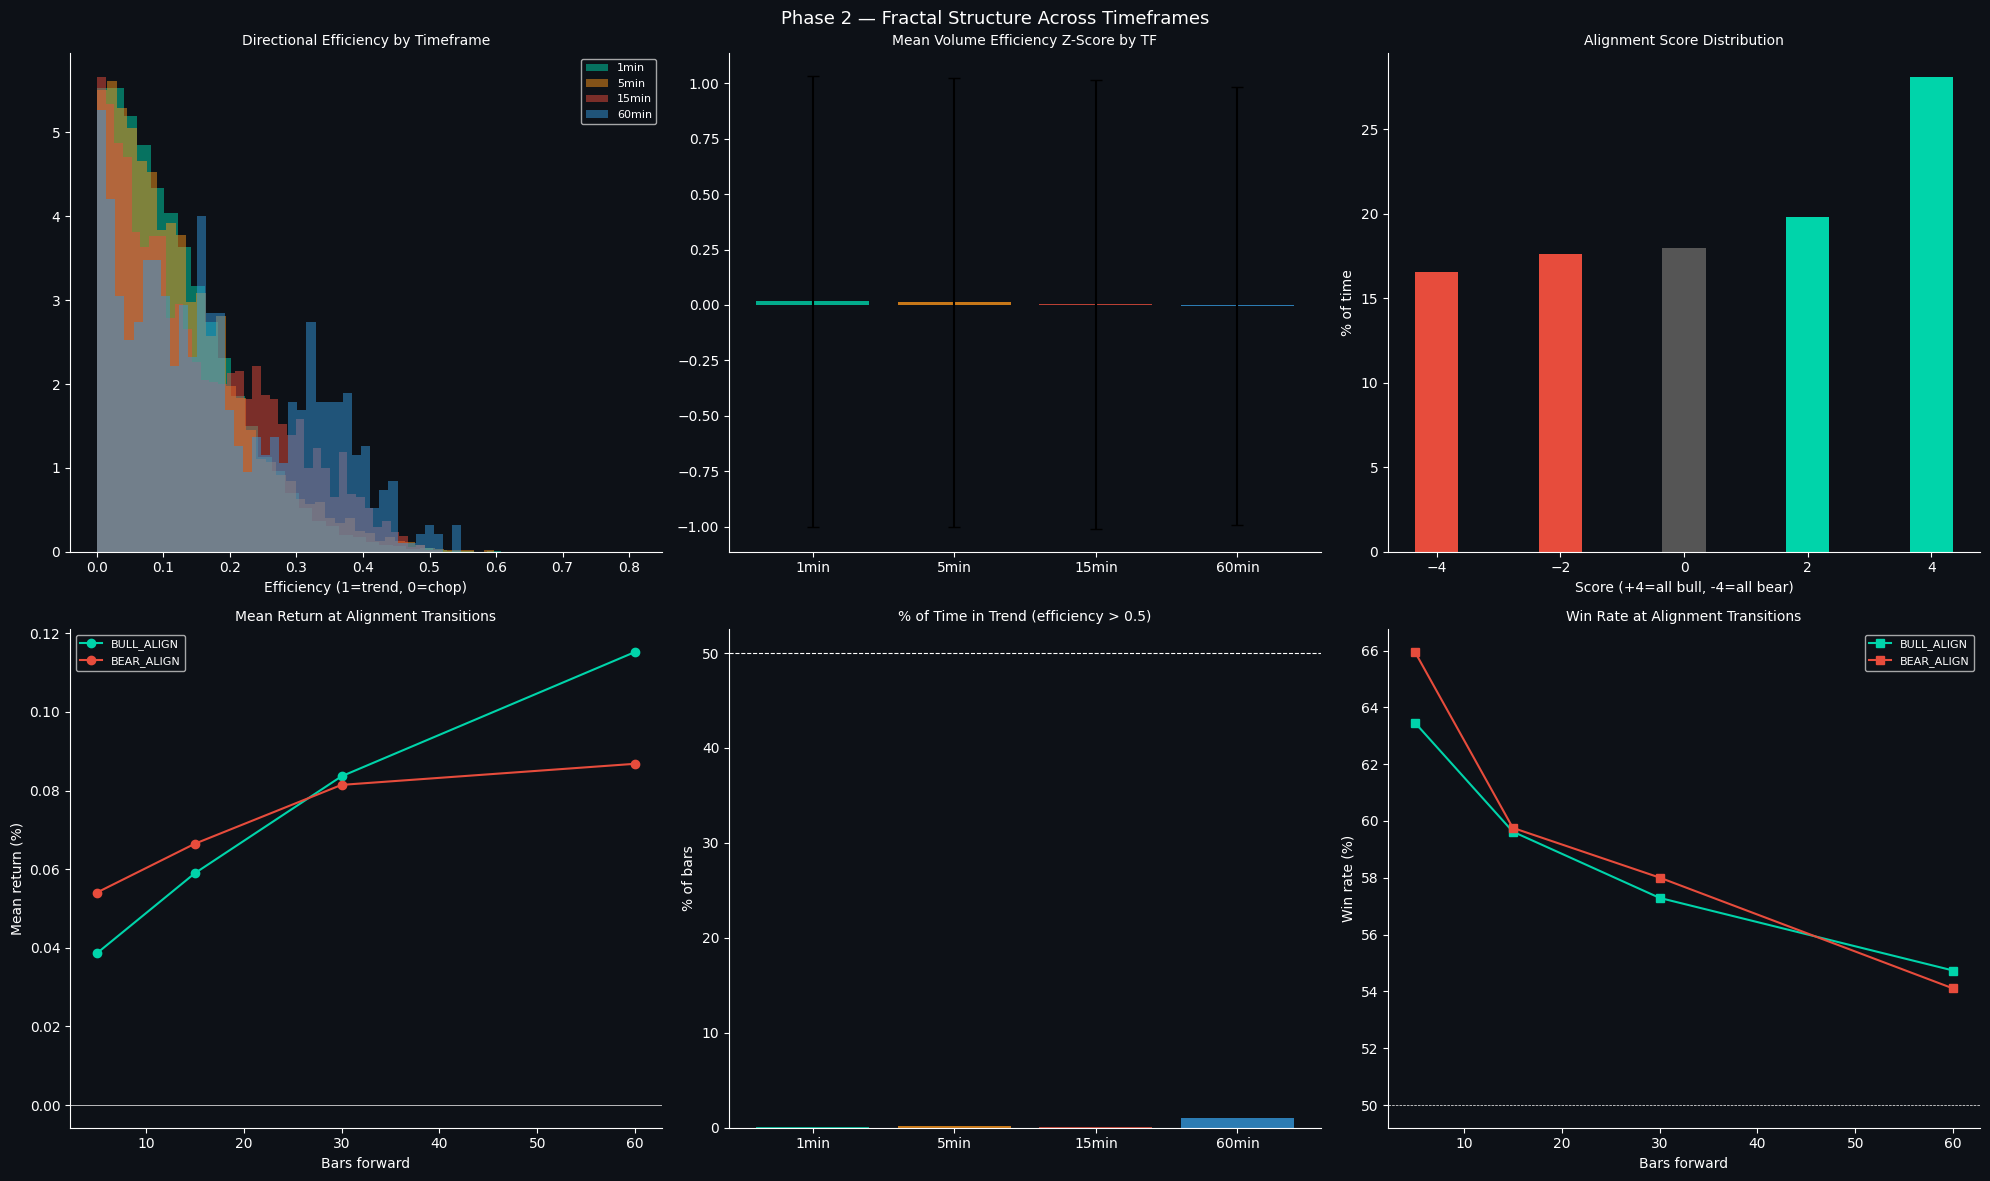

Phase 2 plots saved.


In [18]:
# ── Phase 2C: Fractal Plots ────────────────────────────────────────────────

BG, TEAL, ORG, RED, BLUE = OBS['BG'],OBS['TEAL'],OBS['ORANGE'],OBS['RED'],OBS['BLUE']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.patch.set_facecolor(BG)
fig.suptitle('Phase 2 — Fractal Structure Across Timeframes', color='white', fontsize=13)

# Plot 1: Directional efficiency distribution by TF
ax = axes[0, 0]
ax.set_facecolor(BG)
colors_tf = [TEAL, ORG, RED, BLUE]
for i, tf in enumerate(OBS['FRACTAL_TFS']):
    data = tf_features[tf]['dir_efficiency'].clip(0,1)
    ax.hist(data, bins=40, density=True, alpha=0.5,
            color=colors_tf[i], label=tf)
ax.set_title('Directional Efficiency by Timeframe', color='white', fontsize=10)
ax.set_xlabel('Efficiency (1=trend, 0=chop)', color='white')
ax.tick_params(colors='white')
ax.legend(fontsize=8, labelcolor='white', facecolor=BG)
ax.spines[['top','right']].set_visible(False)

# Plot 2: Volume efficiency by TF
ax = axes[0, 1]
ax.set_facecolor(BG)
means = [tf_features[tf]['vol_eff_z'].mean() for tf in OBS['FRACTAL_TFS']]
stds  = [tf_features[tf]['vol_eff_z'].std()  for tf in OBS['FRACTAL_TFS']]
ax.bar(OBS['FRACTAL_TFS'], means, yerr=stds, color=colors_tf, alpha=0.8, capsize=4)
ax.set_title('Mean Volume Efficiency Z-Score by TF', color='white', fontsize=10)
ax.tick_params(colors='white')
ax.spines[['top','right']].set_visible(False)

# Plot 3: Alignment score distribution
ax = axes[0, 2]
ax.set_facecolor(BG)
n_tfs = len(OBS['FRACTAL_TFS'])
score_counts = align_df['align_score'].value_counts().sort_index()
clrs = [TEAL if s > 0 else (RED if s < 0 else OBS['GREY']) for s in score_counts.index]
ax.bar(score_counts.index, score_counts.values / len(align_df) * 100, color=clrs, width=0.7)
ax.set_title('Alignment Score Distribution', color='white', fontsize=10)
ax.set_xlabel(f'Score (+{n_tfs}=all bull, -{n_tfs}=all bear)', color='white')
ax.set_ylabel('% of time', color='white')
ax.tick_params(colors='white')
ax.spines[['top','right']].set_visible(False)

# Plot 4: Forward return at bull vs bear alignment transitions
ax = axes[1, 0]
ax.set_facecolor(BG)
if len(align_results) > 10:
    for sig, col in [('BULL_ALIGN', TEAL), ('BEAR_ALIGN', RED)]:
        sub = align_results[align_results['type']==sig].groupby('fwd_bars')['ret_pct'].mean()
        ax.plot(sub.index, sub.values, color=col, marker='o', label=sig)
    ax.axhline(0, color='white', lw=0.5)
    ax.set_title('Mean Return at Alignment Transitions', color='white', fontsize=10)
    ax.set_xlabel('Bars forward', color='white')
    ax.set_ylabel('Mean return (%)', color='white')
    ax.legend(fontsize=8, labelcolor='white', facecolor=BG)
ax.tick_params(colors='white')
ax.spines[['top','right']].set_visible(False)

# Plot 5: % of time in trend vs range per TF
ax = axes[1, 1]
ax.set_facecolor(BG)
trend_pct = []
for tf in OBS['FRACTAL_TFS']:
    eff = tf_features[tf]['dir_efficiency']
    trend_pct.append((eff > 0.5).mean() * 100)  # >0.5 efficiency = trending
ax.bar(OBS['FRACTAL_TFS'], trend_pct, color=colors_tf, alpha=0.8)
ax.axhline(50, color='white', lw=0.8, ls='--')
ax.set_title('% of Time in Trend (efficiency > 0.5)', color='white', fontsize=10)
ax.set_ylabel('% of bars', color='white')
ax.tick_params(colors='white')
ax.spines[['top','right']].set_visible(False)

# Plot 6: Win rate at alignment transitions by forward horizon
ax = axes[1, 2]
ax.set_facecolor(BG)
if len(align_results) > 10:
    for sig, col in [('BULL_ALIGN', TEAL), ('BEAR_ALIGN', RED)]:
        sub = align_results[align_results['type']==sig].groupby(
            'fwd_bars')['ret_pct'].apply(lambda x: (x>0).mean()*100)
        ax.plot(sub.index, sub.values, color=col, marker='s', label=sig)
    ax.axhline(50, color='white', lw=0.5, ls='--')
    ax.set_title('Win Rate at Alignment Transitions', color='white', fontsize=10)
    ax.set_xlabel('Bars forward', color='white')
    ax.set_ylabel('Win rate (%)', color='white')
    ax.legend(fontsize=8, labelcolor='white', facecolor=BG)
ax.tick_params(colors='white')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
if OBS['SAVE_PLOTS']:
    plt.savefig('phase2_fractal.png', dpi=OBS['PLOT_DPI'],
                bbox_inches='tight', facecolor=BG)
plt.show()
print('Phase 2 plots saved.')

## Phase 3 — Volume at Key Moments (Reversals and Breakouts)
Identifies reversals and breakouts from price structure.
Measures volume, delta, taker ratio, and volume efficiency at each event.
Tests: does displacement require volume? Do failed breakouts have lower volume?

Events identified: 233
                    vol_rel  vol_eff_z  taker_ratio
event_type genuine                                 
BREAKOUT   False     3.8040     0.2500       0.5200
           True      4.1660     0.0240       0.5440
REVERSAL   False     2.7250     0.6960       0.4770
           True      3.2900     0.5670       0.4510

Breakout vol test (genuine > failed):
  Genuine  vol mean: 4.166x  (n=65)
  Failed   vol mean: 3.804x  (n=116)
  p-value: 0.1176 — Not confirmed


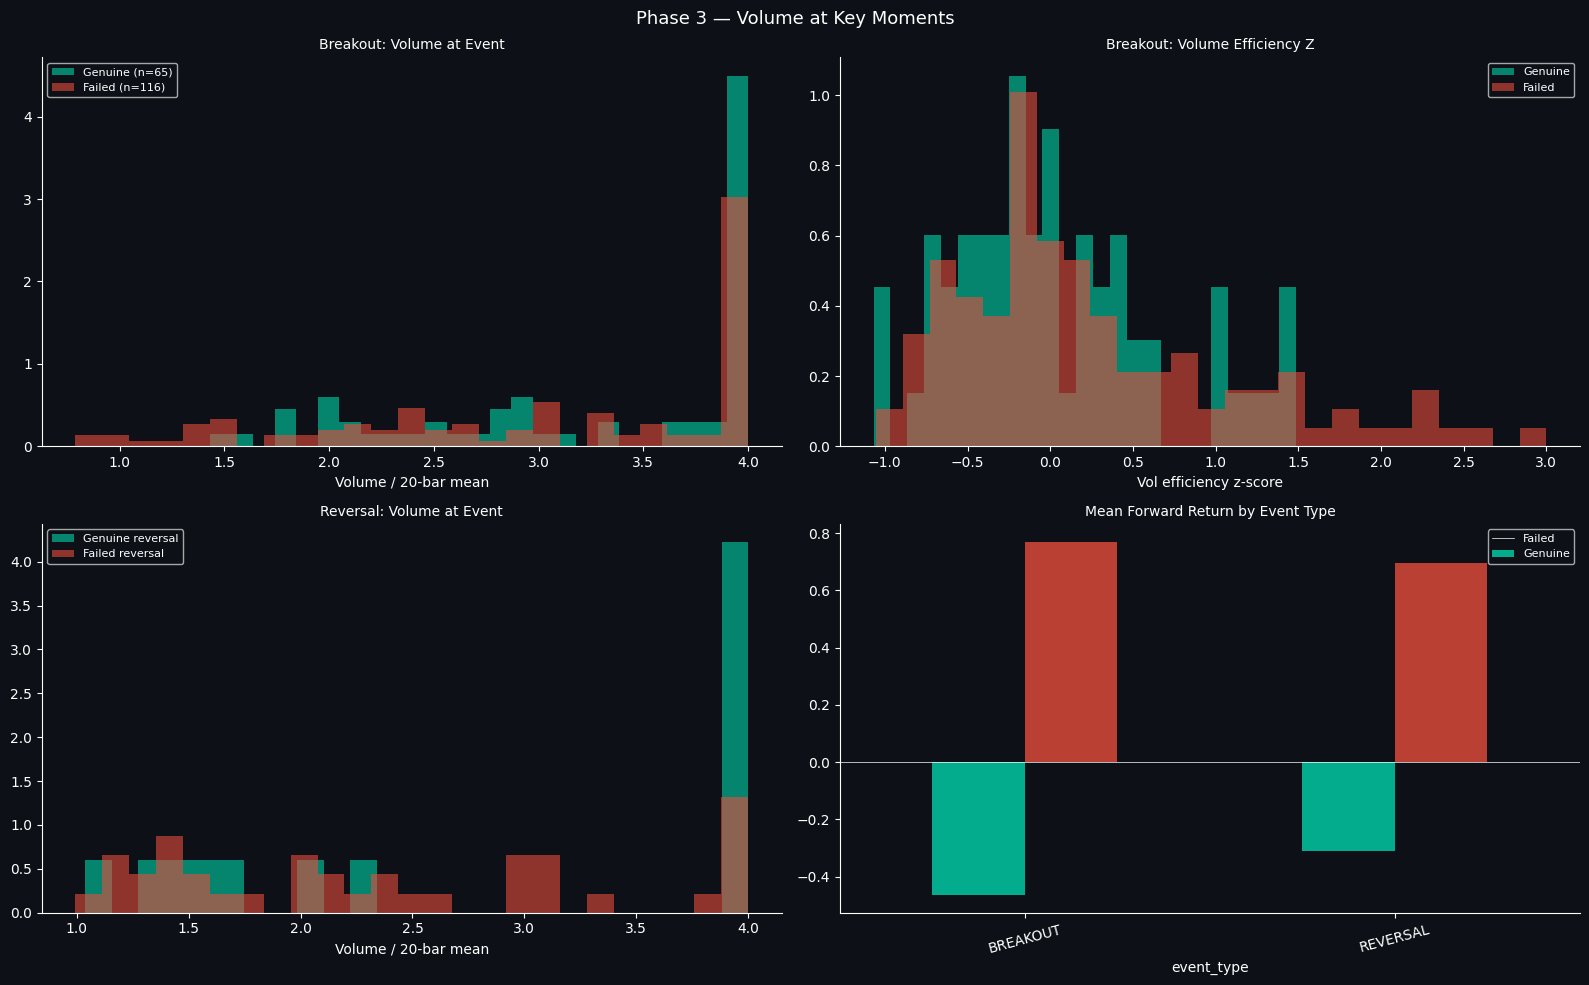

Phase 3 complete.


In [19]:
# ── Phase 3: Volume at Key Moments ────────────────────────────────────────

df5p = TF_MAP['5min'].copy()
df5p['atr']      = compute_atr(df5p, OBS['ATR_PERIOD'])
df5p['vol_ma']   = df5p['volume'].rolling(OBS['VOL_MA_WINDOW']).mean()
df5p['vol_rel']  = df5p['volume'] / (df5p['vol_ma'] + 1e-10)
df5p['taker_ratio'] = df5p['taker_buy_volume'] / (df5p['volume'] + 1e-10)
df5p['bar_move'] = (df5p['close'] - df5p['open']).abs()
df5p['vol_eff']  = df5p['bar_move'] / (df5p['volume'] + 1e-10)
df5p['vol_eff_z'] = (df5p['vol_eff'] - df5p['vol_eff'].rolling(20).mean()) / \
                    (df5p['vol_eff'].rolling(20).std() + 1e-10)
df5p['log_ret']  = np.log(df5p['close'] / df5p['close'].shift(1))
df5p['delta']    = df5p['taker_buy_volume'] - (df5p['volume'] - df5p['taker_buy_volume'])

# ── Identify Events ──────────────────────────────────────────────────────
roll_high = df5p['high'].rolling(20).max().shift(1)
roll_low  = df5p['low'].rolling(20).min().shift(1)

# Breakout: close breaks above 20-bar high with big move
df5p['breakout_up']   = (df5p['close'] > roll_high) & \
                        (df5p['bar_move'] > OBS['BREAKOUT_ATR_MULT'] * df5p['atr'])
df5p['breakout_down'] = (df5p['close'] < roll_low) & \
                        (df5p['bar_move'] > OBS['BREAKOUT_ATR_MULT'] * df5p['atr'])

# Reversal: big move opposing recent direction
df5p['prior_5_ret'] = df5p['log_ret'].rolling(5).sum().shift(1)
df5p['reversal_up']   = (df5p['log_ret'] > OBS['REVERSAL_ATR_MULT'] * df5p['atr'] / df5p['close']) & \
                        (df5p['prior_5_ret'] < -0.002)
df5p['reversal_down'] = (df5p['log_ret'] < -OBS['REVERSAL_ATR_MULT'] * df5p['atr'] / df5p['close']) & \
                        (df5p['prior_5_ret'] > 0.002)

# Classify: was a breakout genuine (continued) or failed (reversed)?
fwd_bars = 12  # 1 hour of 5m bars
event_data = []

closes5 = df5p['close'].values
idx5    = df5p.index

for event_col, direction, event_type in [
    ('breakout_up',   +1, 'BREAKOUT'),
    ('breakout_down', -1, 'BREAKOUT'),
    ('reversal_up',   +1, 'REVERSAL'),
    ('reversal_down', -1, 'REVERSAL'),
]:
    mask = df5p[event_col]
    for ts in idx5[mask]:
        loc = df5p.index.get_loc(ts)
        if loc < 20 or loc > len(df5p) - fwd_bars - 1:
            continue
        row = df5p.iloc[loc]
        fwd_ret = direction * (closes5[loc+fwd_bars] / closes5[loc] - 1) * 100
        genuine = fwd_ret > 0.1  # continued in intended direction

        event_data.append({
            'event_type'  : event_type,
            'direction'   : direction,
            'genuine'     : genuine,
            'vol_rel'     : row['vol_rel'],
            'vol_eff_z'   : row['vol_eff_z'],
            'taker_ratio' : row['taker_ratio'],
            'delta'       : row['delta'],
            'fwd_ret'     : fwd_ret,
        })

event_df = pd.DataFrame(event_data)
print(f'Events identified: {len(event_df):,}')
print(event_df.groupby(['event_type','genuine'])[['vol_rel','vol_eff_z','taker_ratio']]
      .mean().round(3))

# Key test: vol_rel at genuine vs failed breakouts
bo = event_df[event_df['event_type']=='BREAKOUT']
if len(bo) > 20:
    gen = bo[bo['genuine']]['vol_rel']
    fail = bo[~bo['genuine']]['vol_rel']
    stat, p = stats.mannwhitneyu(gen, fail, alternative='greater')
    print(f'\nBreakout vol test (genuine > failed):')
    print(f'  Genuine  vol mean: {gen.mean():.3f}x  (n={len(gen)})')
    print(f'  Failed   vol mean: {fail.mean():.3f}x  (n={len(fail)})')
    print(f'  p-value: {p:.4f} — {"CONFIRMED: genuine breakouts have higher vol" if p < 0.05 else "Not confirmed"}')

# Phase 3 plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor(BG)
fig.suptitle('Phase 3 — Volume at Key Moments', color='white', fontsize=13)

ax = axes[0,0]; ax.set_facecolor(BG)
if len(bo) > 10:
    ax.hist(bo[bo['genuine']]['vol_rel'].clip(0,4), bins=25,
            color=TEAL, alpha=0.6, density=True, label=f'Genuine (n={len(bo[bo["genuine"]])})')
    ax.hist(bo[~bo['genuine']]['vol_rel'].clip(0,4), bins=25,
            color=RED, alpha=0.6, density=True, label=f'Failed (n={len(bo[~bo["genuine"]])})')
ax.set_title('Breakout: Volume at Event', color='white', fontsize=10)
ax.set_xlabel('Volume / 20-bar mean', color='white')
ax.legend(fontsize=8, labelcolor='white', facecolor=BG)
ax.tick_params(colors='white'); ax.spines[['top','right']].set_visible(False)

ax = axes[0,1]; ax.set_facecolor(BG)
if len(bo) > 10:
    ax.hist(bo[bo['genuine']]['vol_eff_z'].clip(-3,3), bins=25,
            color=TEAL, alpha=0.6, density=True, label='Genuine')
    ax.hist(bo[~bo['genuine']]['vol_eff_z'].clip(-3,3), bins=25,
            color=RED, alpha=0.6, density=True, label='Failed')
ax.set_title('Breakout: Volume Efficiency Z', color='white', fontsize=10)
ax.set_xlabel('Vol efficiency z-score', color='white')
ax.legend(fontsize=8, labelcolor='white', facecolor=BG)
ax.tick_params(colors='white'); ax.spines[['top','right']].set_visible(False)

ax = axes[1,0]; ax.set_facecolor(BG)
rev = event_df[event_df['event_type']=='REVERSAL']
if len(rev) > 10:
    ax.hist(rev[rev['genuine']]['vol_rel'].clip(0,4), bins=25,
            color=TEAL, alpha=0.6, density=True, label='Genuine reversal')
    ax.hist(rev[~rev['genuine']]['vol_rel'].clip(0,4), bins=25,
            color=RED, alpha=0.6, density=True, label='Failed reversal')
ax.set_title('Reversal: Volume at Event', color='white', fontsize=10)
ax.set_xlabel('Volume / 20-bar mean', color='white')
ax.legend(fontsize=8, labelcolor='white', facecolor=BG)
ax.tick_params(colors='white'); ax.spines[['top','right']].set_visible(False)

ax = axes[1,1]; ax.set_facecolor(BG)
if len(event_df) > 10:
    grp = event_df.groupby(['event_type','genuine'])['fwd_ret'].mean().unstack()
    grp.plot(kind='bar', ax=ax, color=[TEAL, RED], alpha=0.8)
    ax.axhline(0, color='white', lw=0.5)
ax.set_title('Mean Forward Return by Event Type', color='white', fontsize=10)
ax.tick_params(colors='white', axis='x', rotation=15)
ax.tick_params(colors='white', axis='y')
ax.legend(['Failed','Genuine'], fontsize=8, labelcolor='white', facecolor=BG)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
if OBS['SAVE_PLOTS']:
    plt.savefig('phase3_volume_events.png', dpi=OBS['PLOT_DPI'],
                bbox_inches='tight', facecolor=BG)
plt.show()
print('Phase 3 complete.')

## Phase 4 — VWAP: Price and Volume Behaviour at Key Intersections
Uses 1σ and 2σ standard deviation bands.
Measures what price and volume do at VWAP touches, 1σ, and 2σ.
Tests correlation with previous session high/low as confluence levels.

Computing VWAP with standard deviation bands...
VWAP touch events: 44,070

Mean abs return by event and forward horizon:
fwd_bars         5      15     30
event                            
1SD_DN       0.0881 0.1493 0.2003
1SD_UP       0.0847 0.1437 0.2022
2SD_DN       0.1020 0.1638 0.2218
2SD_UP       0.1058 0.1813 0.2534
VWAP         0.0869 0.1388 0.1908
VWAP_PREV_HL 0.1291 0.2099 0.2822

Mean volume at each event type:
event
1SD_DN         0.9180
1SD_UP         0.9860
2SD_DN         1.0480
2SD_UP         0.9840
VWAP           1.0000
VWAP_PREV_HL   1.0510
Name: vol_rel, dtype: float64


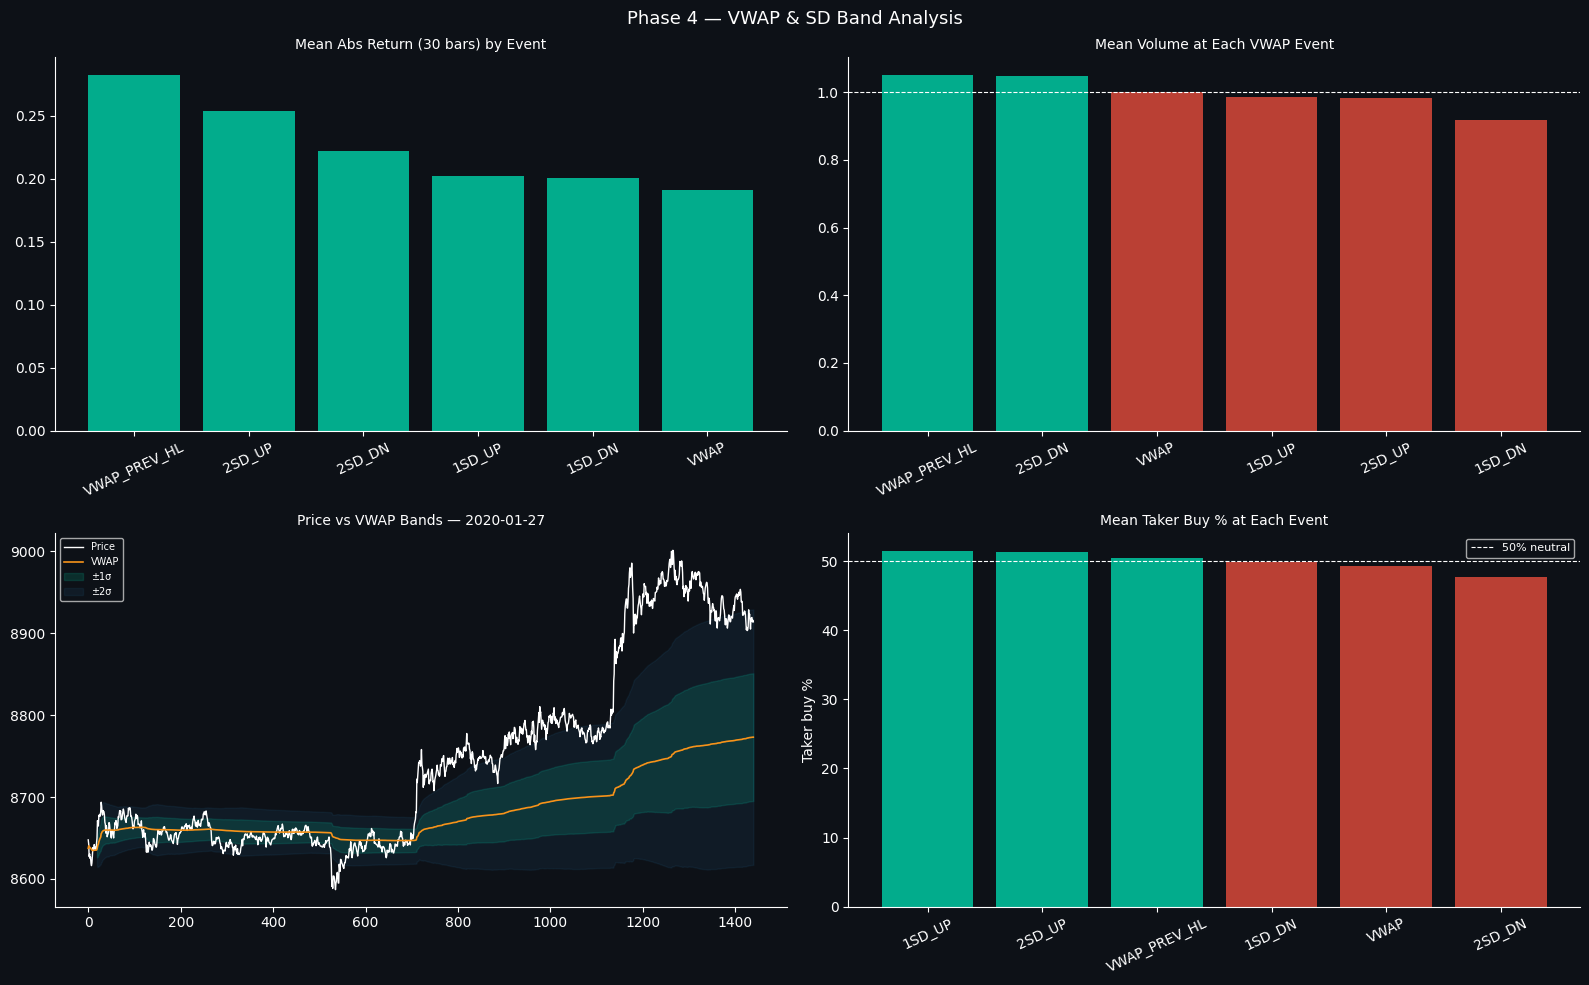

Phase 4 complete.


In [20]:
# ── Phase 4: VWAP Analysis ────────────────────────────────────────────────

print('Computing VWAP with standard deviation bands...')

df_vwap = df1m.copy()
df_vwap['tp']   = (df_vwap['high'] + df_vwap['low'] + df_vwap['close']) / 3
df_vwap['tpv']  = df_vwap['tp'] * df_vwap['volume']
df_vwap['date'] = df_vwap.index.date

# Daily cumulative VWAP and standard deviation
df_vwap['cum_tpv']   = df_vwap.groupby('date')['tpv'].cumsum()
df_vwap['cum_vol']   = df_vwap.groupby('date')['volume'].cumsum()
df_vwap['vwap']      = df_vwap['cum_tpv'] / (df_vwap['cum_vol'] + 1e-10)
df_vwap['vwap_dev']  = df_vwap['close'] - df_vwap['vwap']

# Standard deviation of price from VWAP — rolling within session
df_vwap['session_bar'] = df_vwap.groupby('date').cumcount()
df_vwap['vwap_std']    = df_vwap.groupby('date')['vwap_dev'].transform(
    lambda x: x.expanding(min_periods=20).std()
)

df_vwap['vwap_1sd_up']  = df_vwap['vwap'] + 1.0 * df_vwap['vwap_std']
df_vwap['vwap_1sd_dn']  = df_vwap['vwap'] - 1.0 * df_vwap['vwap_std']
df_vwap['vwap_2sd_up']  = df_vwap['vwap'] + 2.0 * df_vwap['vwap_std']
df_vwap['vwap_2sd_dn']  = df_vwap['vwap'] - 2.0 * df_vwap['vwap_std']

# Previous session high/low
daily_hl = df1m.groupby('date').agg(day_high=('high','max'), day_low=('low','min'))
daily_hl['prev_high'] = daily_hl['day_high'].shift(1)
daily_hl['prev_low']  = daily_hl['day_low'].shift(1)
df_vwap = df_vwap.join(daily_hl[['prev_high','prev_low']], on='date')

# Identify VWAP touch events and band touch events
touch_pct = OBS['VWAP_TOUCH_PCT']

df_vwap['at_vwap']    = (df_vwap['close'] - df_vwap['vwap']).abs() / df_vwap['vwap'] < touch_pct
df_vwap['at_1sd_up']  = (df_vwap['close'] - df_vwap['vwap_1sd_up']).abs() / df_vwap['vwap'] < touch_pct
df_vwap['at_1sd_dn']  = (df_vwap['close'] - df_vwap['vwap_1sd_dn']).abs() / df_vwap['vwap'] < touch_pct
df_vwap['at_2sd_up']  = (df_vwap['close'] - df_vwap['vwap_2sd_up']).abs() / df_vwap['vwap'] < touch_pct
df_vwap['at_2sd_dn']  = (df_vwap['close'] - df_vwap['vwap_2sd_dn']).abs() / df_vwap['vwap'] < touch_pct

# Near previous session high/low
df_vwap['near_prev_high'] = (df_vwap['close'] - df_vwap['prev_high']).abs() / \
                             df_vwap['close'] < touch_pct * 5
df_vwap['near_prev_low']  = (df_vwap['close'] - df_vwap['prev_low']).abs() / \
                             df_vwap['close'] < touch_pct * 5

# Confluence: VWAP touch AND near previous session level
df_vwap['vwap_prev_confluence'] = df_vwap['at_vwap'] & \
    (df_vwap['near_prev_high'] | df_vwap['near_prev_low'])

# Measure forward return and volume at each event type
vwap_events = []
closes_v = df_vwap['close'].values
vols_v   = df_vwap['vol_rel'].values
takers_v = df_vwap['taker_ratio'].values
idx_v    = df_vwap.index

event_masks = [
    ('VWAP',          df_vwap['at_vwap']),
    ('1SD_UP',        df_vwap['at_1sd_up']),
    ('1SD_DN',        df_vwap['at_1sd_dn']),
    ('2SD_UP',        df_vwap['at_2sd_up']),
    ('2SD_DN',        df_vwap['at_2sd_dn']),
    ('VWAP_PREV_HL',  df_vwap['vwap_prev_confluence']),
]

for event_name, mask in event_masks:
    for i, ts in enumerate(idx_v[mask]):
        loc = np.searchsorted(idx_v, ts)
        if loc >= len(closes_v) - 30:
            continue
        px = closes_v[loc]
        for fwd in OBS['VWAP_FWD_BARS']:
            if loc + fwd < len(closes_v):
                ret = (closes_v[loc+fwd] / px - 1) * 100
                vwap_events.append({
                    'event'      : event_name,
                    'fwd_bars'   : fwd,
                    'ret_pct'    : ret,
                    'abs_ret'    : abs(ret),
                    'vol_rel'    : vols_v[loc],
                    'taker'      : takers_v[loc],
                })

vwap_df_results = pd.DataFrame(vwap_events)

print(f'VWAP touch events: {len(vwap_df_results):,}')
if len(vwap_df_results) > 0:
    print('\nMean abs return by event and forward horizon:')
    print(vwap_df_results.groupby(['event','fwd_bars'])['abs_ret']
          .mean().unstack().round(4))

    print('\nMean volume at each event type:')
    print(vwap_df_results.groupby('event')['vol_rel'].mean().round(3))

# VWAP plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor(BG)
fig.suptitle('Phase 4 — VWAP & SD Band Analysis', color='white', fontsize=13)

ax = axes[0,0]; ax.set_facecolor(BG)
if len(vwap_df_results) > 0:
    sub30 = vwap_df_results[vwap_df_results['fwd_bars']==30]
    grp = sub30.groupby('event')['abs_ret'].mean().sort_values(ascending=False)
    ax.bar(grp.index, grp.values, color=TEAL, alpha=0.8)
ax.set_title('Mean Abs Return (30 bars) by Event', color='white', fontsize=10)
ax.tick_params(colors='white', axis='x', rotation=25)
ax.tick_params(colors='white', axis='y')
ax.spines[['top','right']].set_visible(False)

ax = axes[0,1]; ax.set_facecolor(BG)
if len(vwap_df_results) > 0:
    grp_vol = vwap_df_results.groupby('event')['vol_rel'].mean().sort_values(ascending=False)
    c = [TEAL if v > 1 else RED for v in grp_vol.values]
    ax.bar(grp_vol.index, grp_vol.values, color=c, alpha=0.8)
    ax.axhline(1.0, color='white', lw=0.8, ls='--')
ax.set_title('Mean Volume at Each VWAP Event', color='white', fontsize=10)
ax.tick_params(colors='white', axis='x', rotation=25)
ax.tick_params(colors='white', axis='y')
ax.spines[['top','right']].set_visible(False)

# Sample day: price vs VWAP bands
ax = axes[1,0]; ax.set_facecolor(BG)
sample_date2 = sorted(df_vwap['date'].unique())[-5]
day_data = df_vwap[df_vwap['date']==sample_date2]
if len(day_data) > 60:
    ax.plot(range(len(day_data)), day_data['close'].values, color='white', lw=1, label='Price')
    ax.plot(range(len(day_data)), day_data['vwap'].values, color=ORG, lw=1.2, label='VWAP')
    ax.fill_between(range(len(day_data)),
                    day_data['vwap_1sd_dn'].values, day_data['vwap_1sd_up'].values,
                    alpha=0.15, color=TEAL, label='±1σ')
    ax.fill_between(range(len(day_data)),
                    day_data['vwap_2sd_dn'].values, day_data['vwap_2sd_up'].values,
                    alpha=0.08, color=BLUE, label='±2σ')
ax.set_title(f'Price vs VWAP Bands — {sample_date2}', color='white', fontsize=10)
ax.legend(fontsize=7, labelcolor='white', facecolor=BG)
ax.tick_params(colors='white')
ax.spines[['top','right']].set_visible(False)

# Taker ratio at each event
ax = axes[1,1]; ax.set_facecolor(BG)
if len(vwap_df_results) > 0:
    grp_t = vwap_df_results.groupby('event')['taker'].mean().sort_values(ascending=False)
    c = [TEAL if t > 0.5 else RED for t in grp_t.values]
    ax.bar(grp_t.index, grp_t.values * 100, color=c, alpha=0.8)
    ax.axhline(50, color='white', lw=0.8, ls='--', label='50% neutral')
ax.set_title('Mean Taker Buy % at Each Event', color='white', fontsize=10)
ax.set_ylabel('Taker buy %', color='white')
ax.legend(fontsize=8, labelcolor='white', facecolor=BG)
ax.tick_params(colors='white', axis='x', rotation=25)
ax.tick_params(colors='white', axis='y')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
if OBS['SAVE_PLOTS']:
    plt.savefig('phase4_vwap.png', dpi=OBS['PLOT_DPI'],
                bbox_inches='tight', facecolor=BG)
plt.show()
print('Phase 4 complete.')

## Summary Cell — Collect All Observations
Prints a single structured summary of all empirical findings.
These numbers become the calibration inputs for the strategy notebook.

In [21]:
# ── Summary: All Empirical Observations ───────────────────────────────────

sep = '='*70
print(sep)
print('  MARKET OBSERVATION SUMMARY')
print(sep)

# Phase 1
print('\nPHASE 1 — VOLUME PROFILE')
if len(touch_df) > 0:
    print('  Forward return (30-bar mean %) when price touches level next session:')
    for lvl_type in ['POC','VAH','VAL','HVN','LVN']:
        sub = touch_df[touch_df['level_type']==lvl_type]['fwd_ret_30']
        if len(sub) > 5:
            print(f'    {lvl_type:<5}: mean={sub.mean():+.4f}%  '
                  f'std={sub.std():.4f}  n={len(sub)}')
    hvn_b = touch_df[(touch_df['level_type']=='HVN')&(touch_df['delta_sign']=='BUY')]['fwd_ret_30']
    hvn_s = touch_df[(touch_df['level_type']=='HVN')&(touch_df['delta_sign']=='SELL')]['fwd_ret_30']
    if len(hvn_b)>5 and len(hvn_s)>5:
        print(f'  HVN buy-delta mean fwd: {hvn_b.mean():+.4f}% vs '
              f'HVN sell-delta: {hvn_s.mean():+.4f}%')

# Phase 1D
print('\nPHASE 1D — DELTA AT SWING ENDPOINTS')
if len(retrace_df) > 0:
    for st in ['SWING_HIGH','SWING_LOW']:
        sub = retrace_df[retrace_df['type']==st]
        rev = sub[sub['reversed']]
        cont = sub[~sub['reversed']]
        if len(rev)>5 and len(cont)>5:
            print(f'  {st}: reversed delta_z={rev["delta_z"].mean():.3f} '
                  f'vs continued delta_z={cont["delta_z"].mean():.3f}')

# Phase 2
print('\nPHASE 2 — FRACTAL STRUCTURE')
for tf in OBS['FRACTAL_TFS']:
    eff = tf_features[tf]['dir_efficiency']
    print(f'  {tf:<6}: mean efficiency={eff.mean():.3f}  '
          f'% trending={((eff>0.5).mean()*100):.1f}%')
if len(align_results) > 0:
    bull_30 = align_results[(align_results['type']=='BULL_ALIGN')&
                            (align_results['fwd_bars']==30)]['ret_pct']
    bear_30 = align_results[(align_results['type']=='BEAR_ALIGN')&
                            (align_results['fwd_bars']==30)]['ret_pct']
    if len(bull_30)>5:
        print(f'  Bull alignment 30-bar return: mean={bull_30.mean():+.4f}% '
              f'win%={(bull_30>0).mean()*100:.1f}%')
    if len(bear_30)>5:
        print(f'  Bear alignment 30-bar return: mean={bear_30.mean():+.4f}% '
              f'win%={(bear_30>0).mean()*100:.1f}%')

# Phase 3
print('\nPHASE 3 — VOLUME AT KEY MOMENTS')
if len(event_df) > 0:
    for et in ['BREAKOUT','REVERSAL']:
        sub = event_df[event_df['event_type']==et]
        gen = sub[sub['genuine']]
        fail = sub[~sub['genuine']]
        if len(gen)>5 and len(fail)>5:
            print(f'  {et}: genuine vol={gen["vol_rel"].mean():.2f}x '
                  f'failed vol={fail["vol_rel"].mean():.2f}x '
                  f'genuine rate={(len(gen)/len(sub)*100):.1f}%')

# Phase 4
print('\nPHASE 4 — VWAP')
if len(vwap_df_results) > 0:
    for event in ['VWAP','1SD_DN','1SD_UP','2SD_DN','2SD_UP','VWAP_PREV_HL']:
        sub = vwap_df_results[(vwap_df_results['event']==event)&
                              (vwap_df_results['fwd_bars']==15)]
        if len(sub) > 5:
            print(f'  {event:<15}: n={len(sub):>5}  '
                  f'mean_abs_ret={sub["abs_ret"].mean():.4f}%  '
                  f'vol={sub["vol_rel"].mean():.2f}x  '
                  f'taker={sub["taker"].mean()*100:.1f}%')

print()
print(sep)
print('  These numbers calibrate the strategy notebook parameters.')
print('  No rules formed here — observe first, decide later.')
print(sep)

  MARKET OBSERVATION SUMMARY

PHASE 1 — VOLUME PROFILE
  Forward return (30-bar mean %) when price touches level next session:
    POC  : mean=-0.0465%  std=0.5641  n=24
    VAH  : mean=+0.1988%  std=0.6869  n=24
    VAL  : mean=+0.0050%  std=0.3804  n=22
    HVN  : mean=+0.0817%  std=0.5509  n=97
    LVN  : mean=+0.2178%  std=0.7956  n=72
  HVN buy-delta mean fwd: +0.1501% vs HVN sell-delta: +0.0250%

PHASE 1D — DELTA AT SWING ENDPOINTS
  SWING_HIGH: reversed delta_z=0.359 vs continued delta_z=0.255
  SWING_LOW: reversed delta_z=-0.464 vs continued delta_z=-0.335

PHASE 2 — FRACTAL STRUCTURE
  1min  : mean efficiency=0.116  % trending=0.1%
  5min  : mean efficiency=0.122  % trending=0.1%
  15min : mean efficiency=0.146  % trending=0.0%
  60min : mean efficiency=0.180  % trending=1.0%
  Bull alignment 30-bar return: mean=+0.0836% win%=57.3%
  Bear alignment 30-bar return: mean=+0.0814% win%=58.0%

PHASE 3 — VOLUME AT KEY MOMENTS
  BREAKOUT: genuine vol=4.17x failed vol=3.80x genuine ra